# Extracting OISST timeseries from green crab study locations.

First import libraries.

In [ ]:
import re
from getpass import getpass

import marimo as mo
import icechunk as ic
import numpy as np
import xarray as xr
import pandas as pd
from pydantic import BaseModel, Field
import geopandas as gpd

Open and explore the source dataframe (once it was externally pruned down to just sites/location).

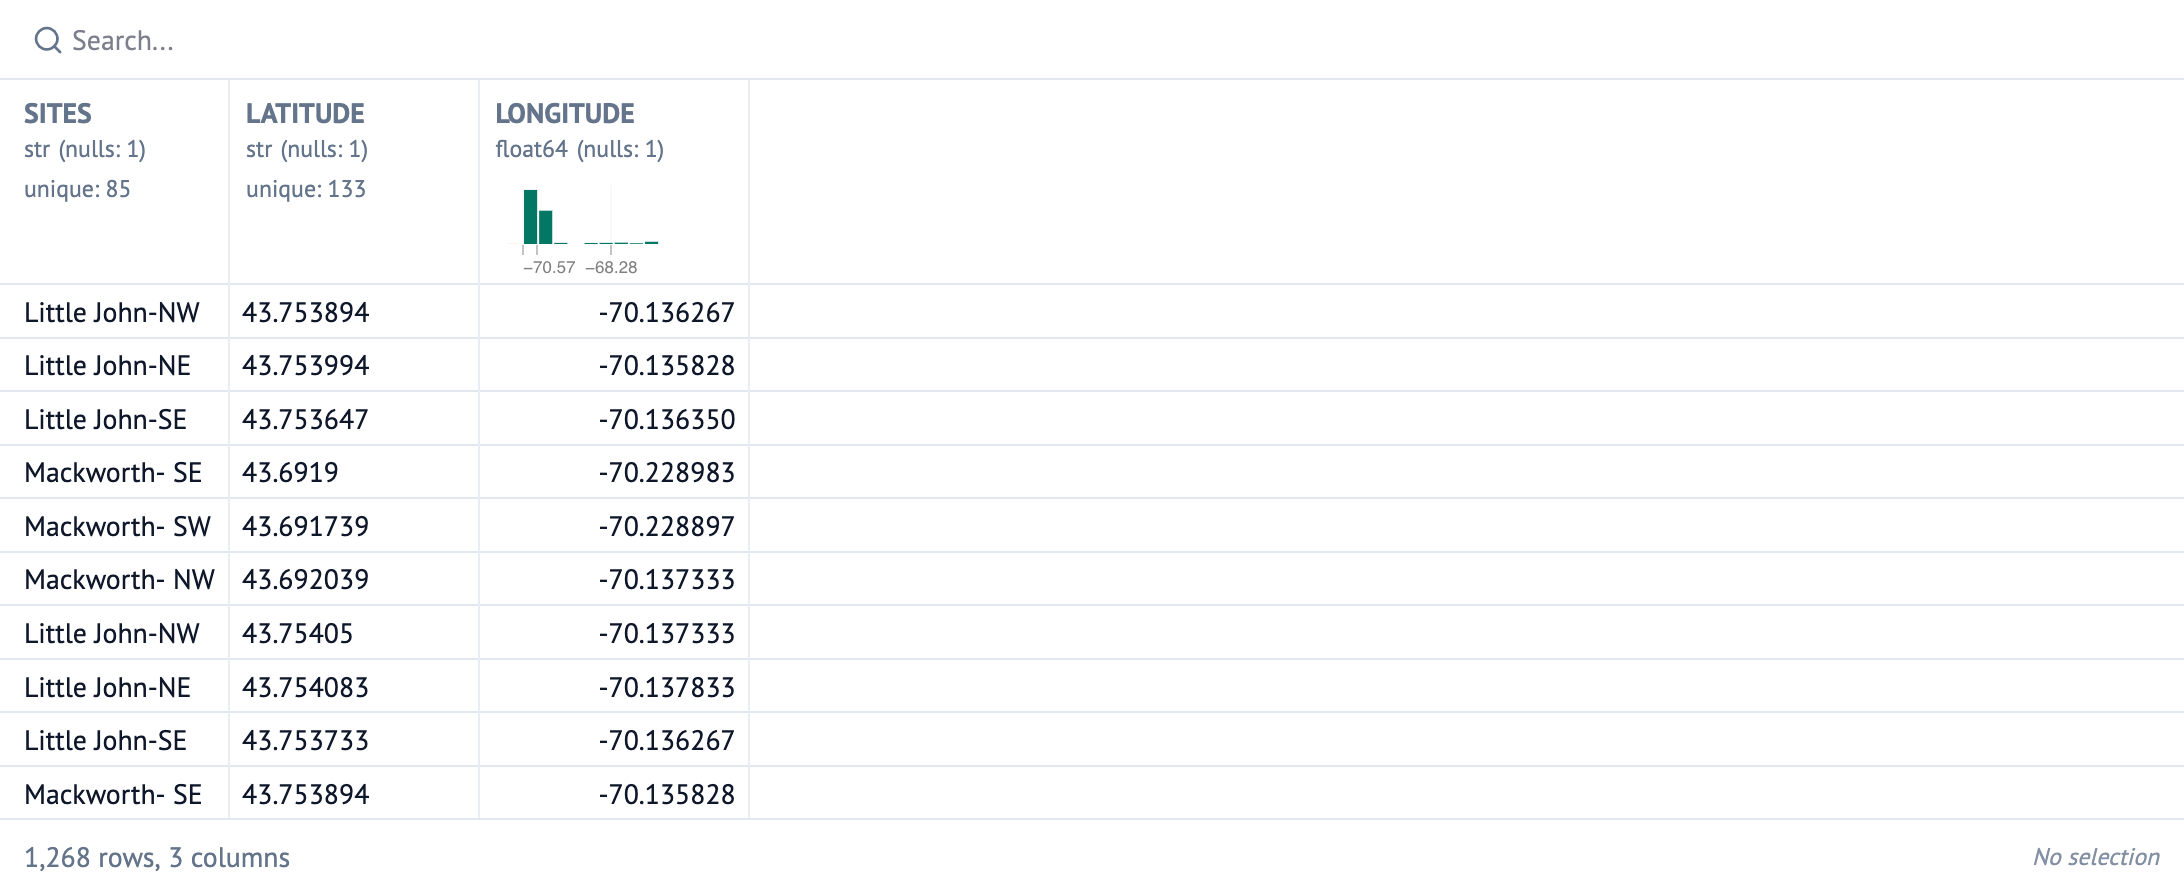

In [ ]:
source_df = pd.read_csv("~/Downloads/Green_Crab_MT_points.csv", engine="python")
source_df

Filter to just unique points (1,268 -> 85 points), and set the site names as the index variable (so they become the coordinate variable).

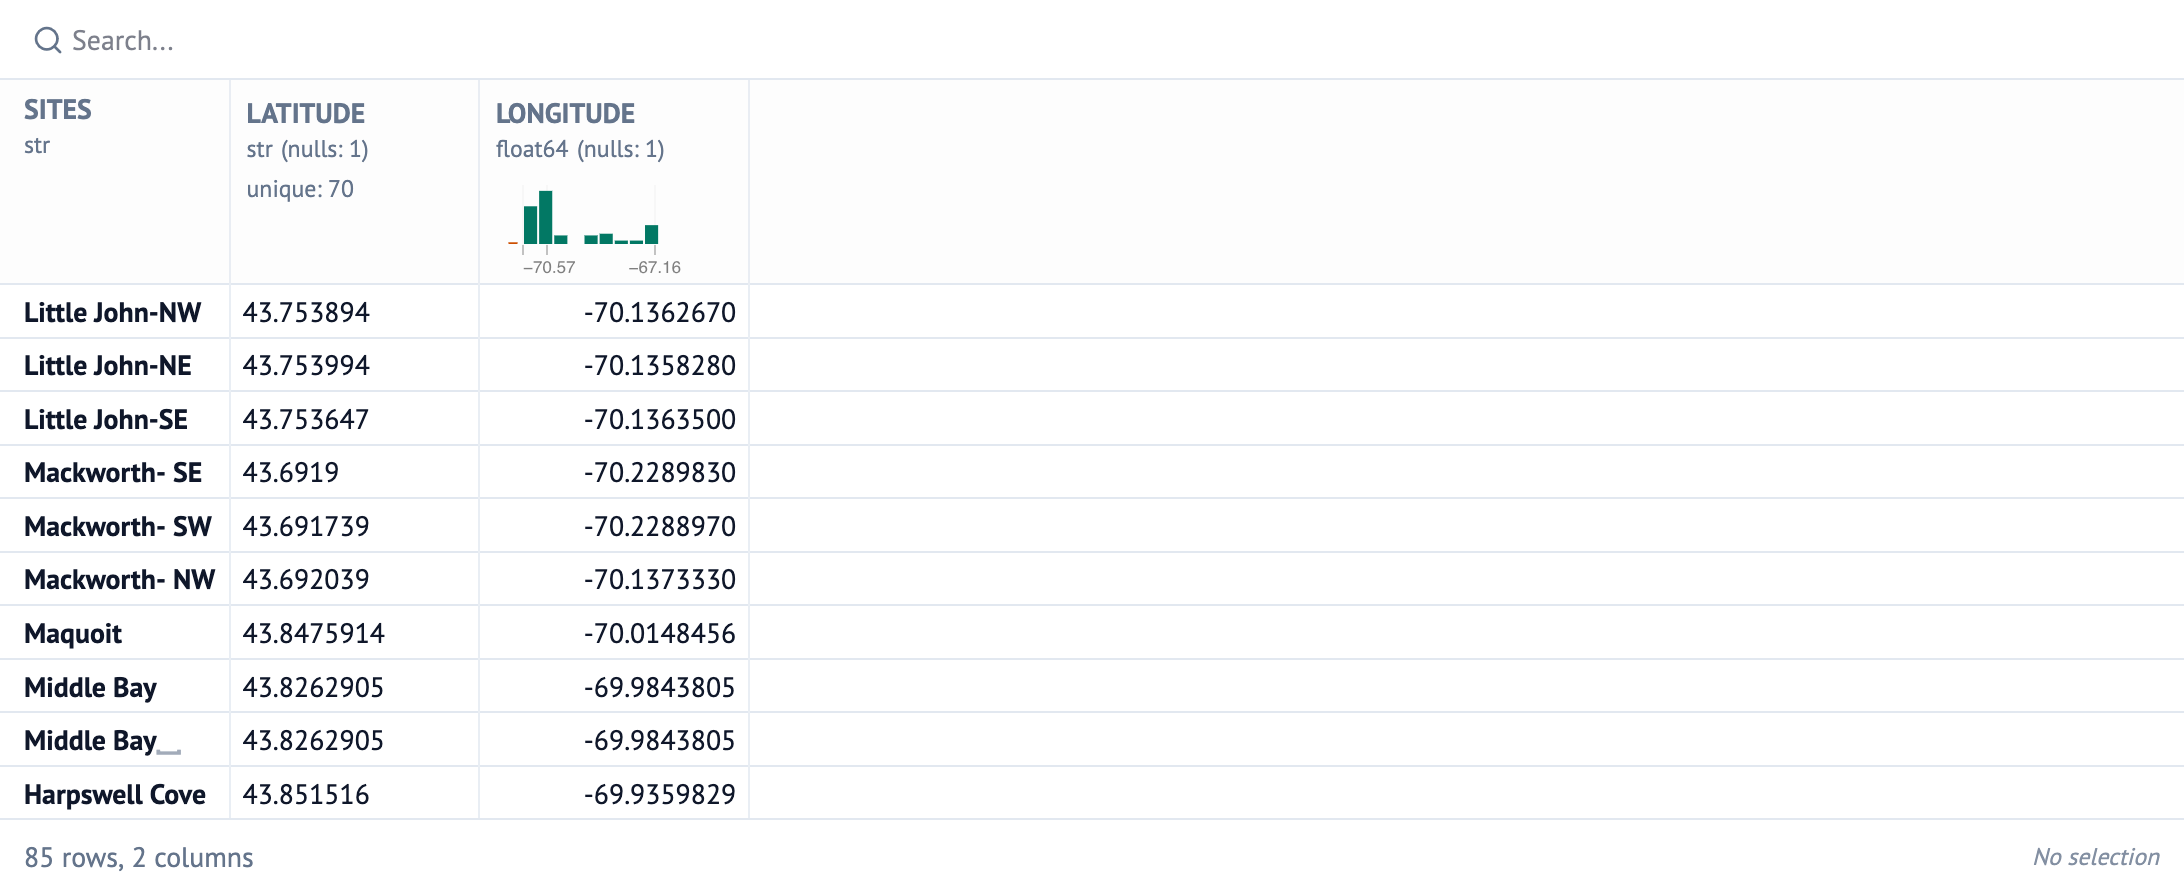

In [ ]:
unique_df = source_df.drop_duplicates(["SITES"]).set_index("SITES")
unique_df

Convert to an Xarray dataset with the point names as a coordinate, and rename the columns to what other operations expect (points, lat, lon).

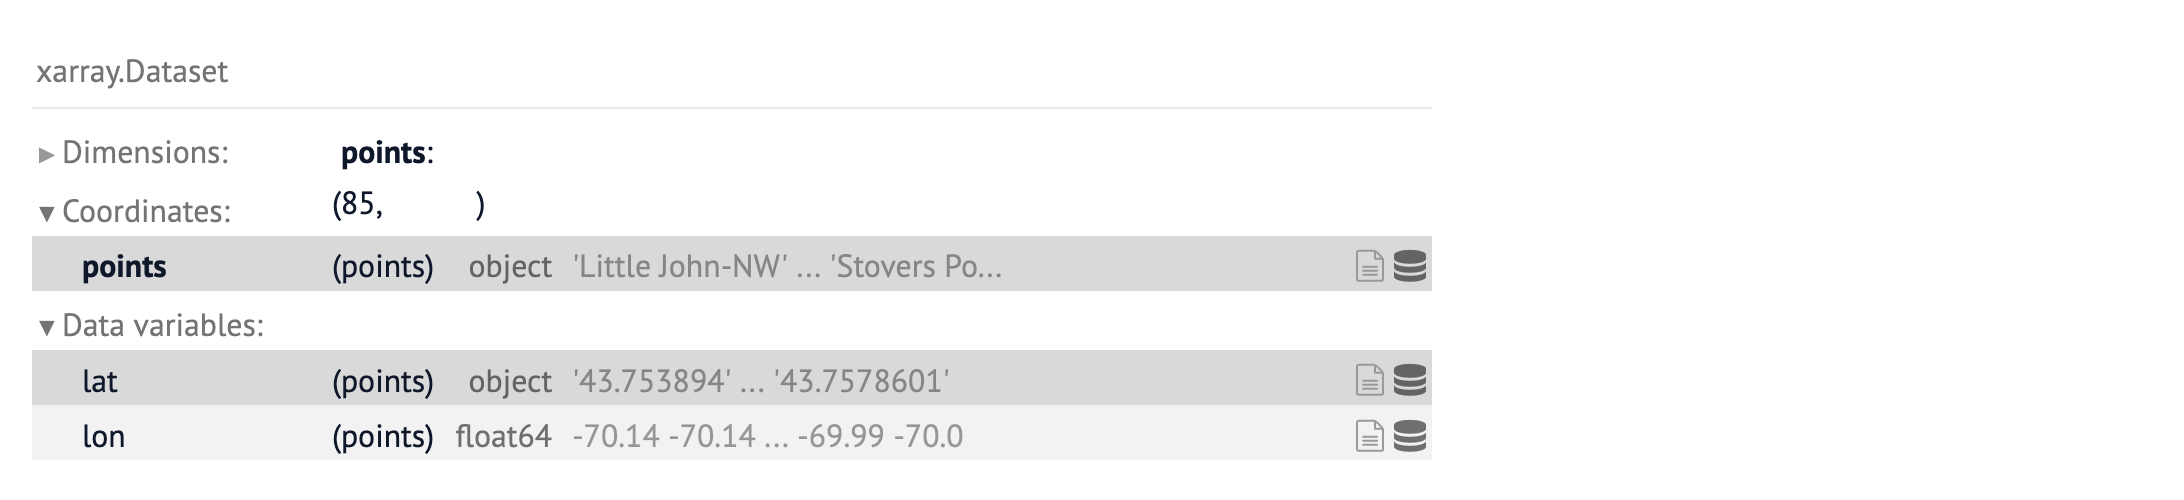

In [ ]:
points_ds = unique_df.to_xarray().rename({"LATITUDE": "lat", "LONGITUDE": "lon", "SITES": "points"})
points_ds

Enter in AWS access credentials for the dataset. The daily dataset itself is in a public bucket, but the metadata and the monthly data is in a NERACOOS requester pays bucket.

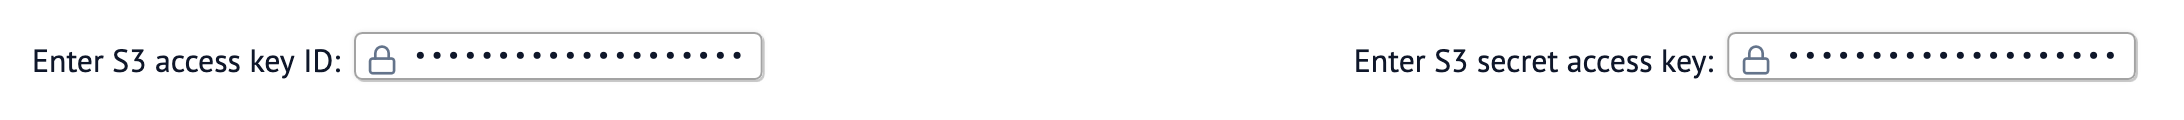

In [ ]:
access_key = mo.ui.text(label="Enter S3 access key ID: ", kind="password")
secret_key = mo.ui.text(label="Enter S3 secret access key: ", kind="password")
mo.hstack([access_key, secret_key])

Some scaffolding to help opening the dataset. The daily data lives in `noaa-cdr-sea-surface-temp-optimum-interpolation-pds`, while the metadata and monthly data is in `neracoos-data-requester-pays`, which makes the access a little convoluted.

In [ ]:
BUCKET = "noaa-cdr-sea-surface-temp-optimum-interpolation-pds"
URL_PREFIX = f"s3://{BUCKET}/"
DATA_PREFIX = "data/v2.1/avhrr"
REGION = "us-east-1"

# obstore / icechunk want the prefix without a trailing slash for the registry
# key, while icechunk's VirtualChunkContainer matches against the trailing-slash
# form (mirroring services/xreds dataset_spec.py).
STORE_PREFIX = URL_PREFIX.rstrip("/")


def open_repo(prefix: str) -> ic.Repository:
    """Open (or create on first run) the icechunk repo for a store prefix, with
    the NOAA virtual chunk container registered and authorized."""
    config = ic.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        ic.VirtualChunkContainer(
            url_prefix=URL_PREFIX,
            store=ic.s3_store(region=REGION, anonymous=True),
        ),
    )

    return ic.Repository.open(
        ic.s3_storage(
            bucket="neracoos-data-requester-pays",
            prefix=prefix,
            region="us-east-1",
            access_key_id=access_key.value,
            secret_access_key=secret_key.value,
            requester_pays=True,
        ),
        config=config,
        authorize_virtual_chunk_access=ic.containers_credentials(
            {URL_PREFIX: ic.s3_anonymous_credentials()}
        ),
    )

Now we can access the metadata, and open a session for access. There are a few steps here because [Icechunk](https://icechunk.io/en/stable/) uses a strong versioning system like Git, but we can use the latest data on `main`.

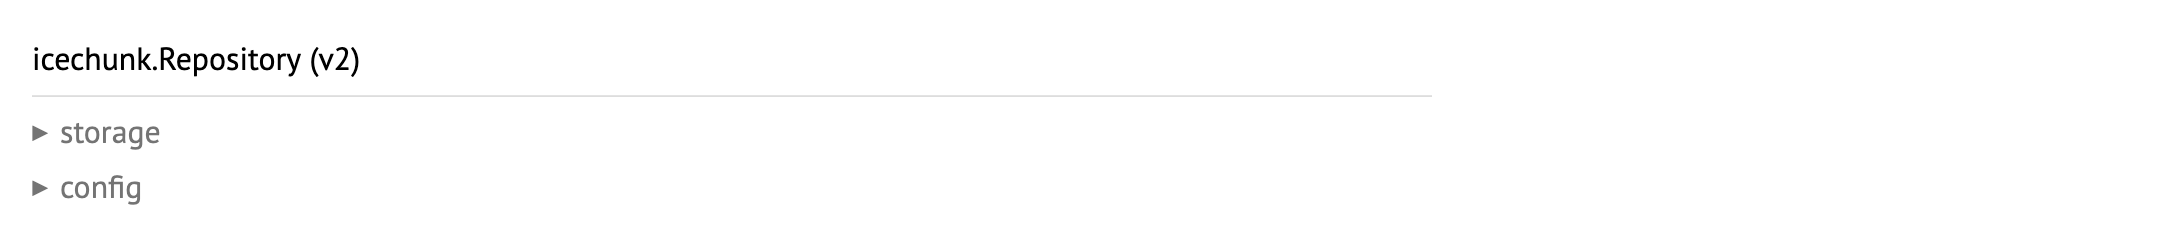

In [ ]:
final_repo = open_repo("oisst/final")
final_repo

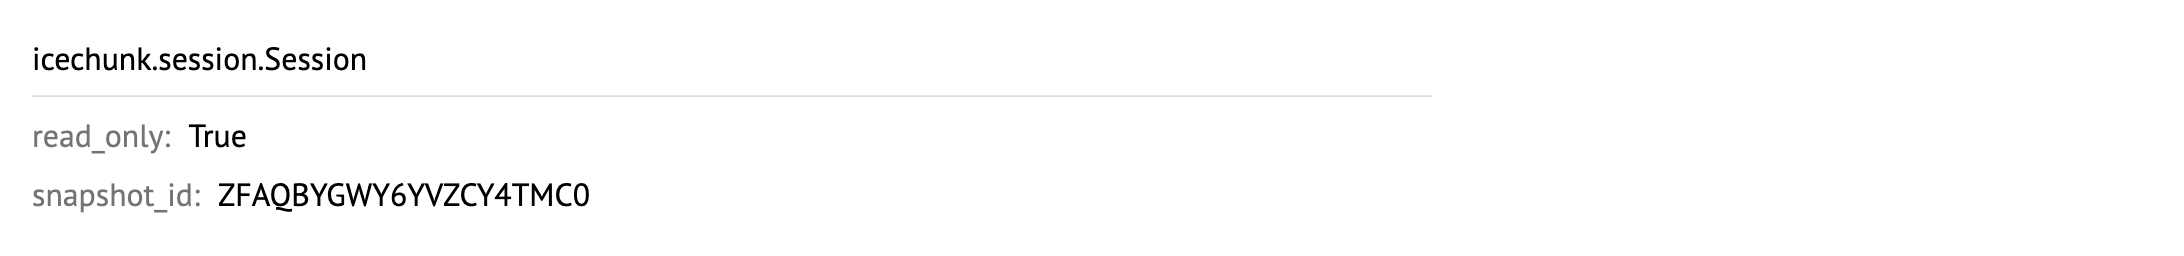

In [ ]:
final_session = final_repo.readonly_session("main")
final_session

Now we open the OISST datatree. The daily data has the 4 normal variables, but the monthly data has those variables aggregated ito mean, min, max, and standard deviation. We're going to use the monthly dataset.

/var/folders/n6/hl07fcc55ys7mbybt01gb8r80000gn/T/marimo_1274/__marimo__cell_ROlb_.py:1: FutureWarning: zarr_version is deprecated, use zarr_format
  oisst_dt = xr.open_datatree(final_session.store, engine="zarr", zarr_version=3)


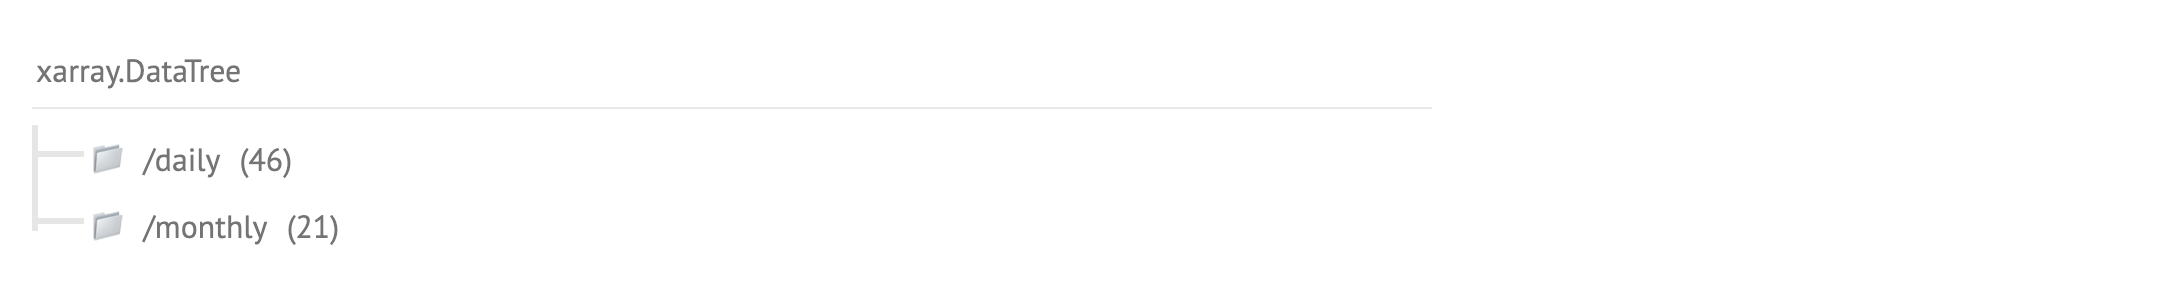

In [ ]:
oisst_dt = xr.open_datatree(final_session.store, engine="zarr", zarr_version=3)
oisst_dt

We're explictly sorting the time as our aggregation process for both daily and monthly data is non linear, and we'd rather not have miss-ordered dates later.

In [ ]:
print(f"Full dataset: {oisst_dt.nbytes / 1_000_000_000:,.2f} Gigabytes")

Full dataset: 615.54 Gigabytes


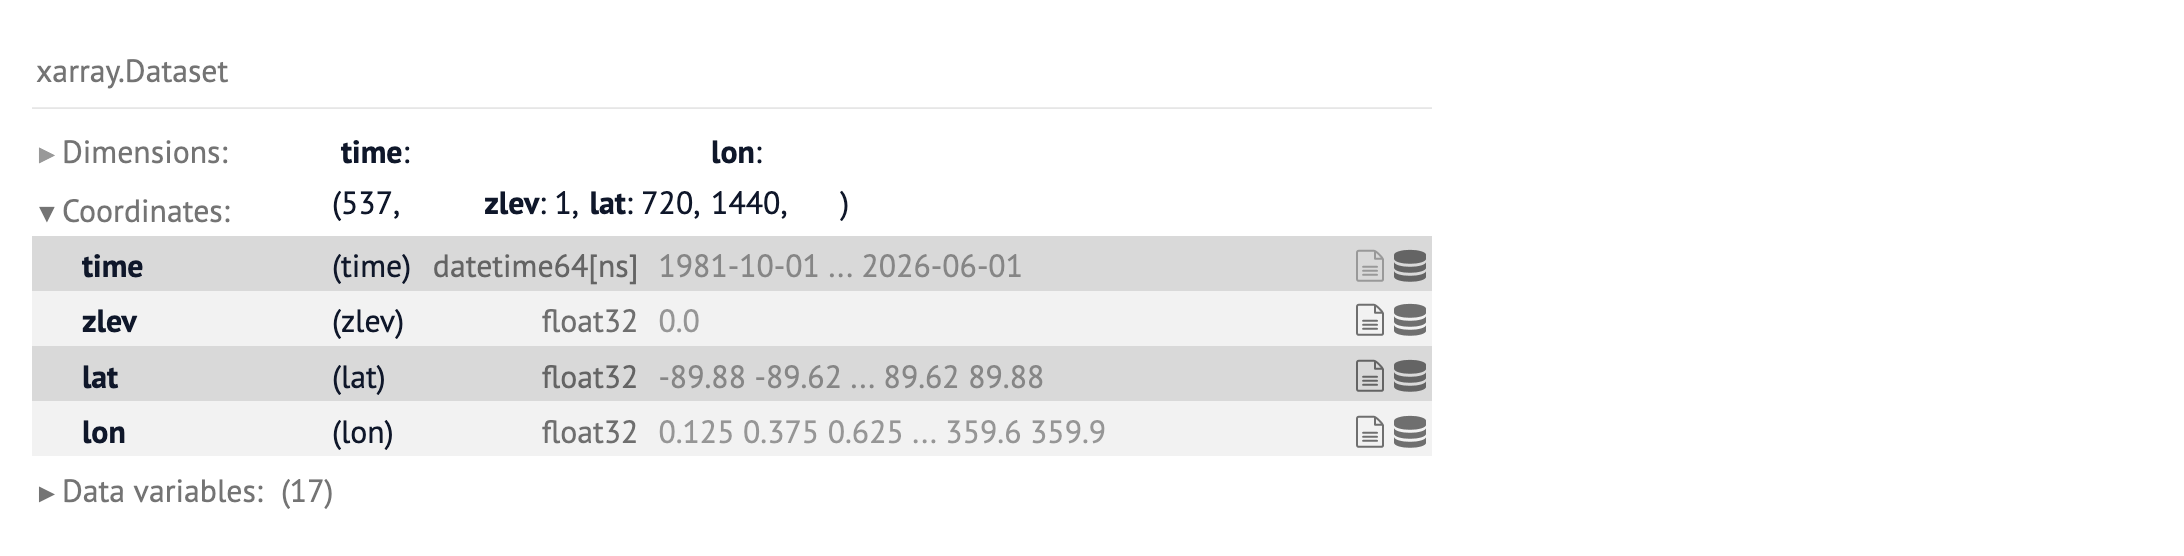

In [ ]:
monthly_ds = oisst_dt["monthly"].to_dataset()
# Or directly with
# monthly_ds = xr.open_zarr(final_session.store, group="monthly", zarr_version=3)
monthly_ds = monthly_ds.sortby("time")
monthly_ds

In [ ]:
print(f"Monthly: {monthly_ds.nbytes / 1_000_000_000:,.2f} bytes")

Monthly: 71.27 bytes


Most of these samples were collected on shore, so we need to find the nearest 'wet' OISST cell. This also handles when our point longitudes are in -180 to 180 vs OISST in 0-360.

In [ ]:
def sel_ocean_points(da, pts, window=1.0):
    """Pointwise-select `da` at each (lat, lon) in `pts`, snapping to ocean cells.

    Handles two gotchas of point extraction from OISST-style grids:

    - **Longitude convention** - converts the points' -180..180 longitudes to
      0..360 when that's what the grid uses (detected from `da.lon.max()`).
    - **Land cells** - a point whose nearest cell is all-null (land) is snapped
      to the nearest non-null (ocean) cell within +/-`window` degrees, using
      the first timestep's null mask as the land/ocean mask.

    Returns a DataArray with a `points` dimension (labels from `pts`), the
    chosen cell's lat/lon as coordinates, and a boolean `snapped` coordinate
    marking points that were moved off land.
    """
    lon_max = float(da.lon.max())
    lons = pts["lon"] % 360 if lon_max > 180 else pts["lon"]
    ocean = da.isel(time=0).notnull().drop_vars("time", errors="ignore")

    series = []
    snapped = []
    for i in range(pts.sizes["points"]):
        t_lat, t_lon = float(pts["lat"][i]), float(lons[i])
        cell = da.sel(lat=t_lat, lon=t_lon, method="nearest")
        if bool(cell.isnull().all()):
            win = da.sel(
                lat=slice(t_lat - window, t_lat + window),
                lon=slice(t_lon - window, t_lon + window),
            )
            dist = (win.lat - t_lat) ** 2 + (win.lon - t_lon) ** 2
            idx = dist.where(ocean.sel(lat=win.lat, lon=win.lon)).argmin(
                dim=("lat", "lon")
            )
            cell = win.isel(idx)
            snapped.append(True)
        else:
            snapped.append(False)
        series.append(cell)

    out = xr.concat(series, dim=pts["points"])
    return out.assign_coords(snapped=("points", snapped))

Now that function helps us [pointwise index](https://docs.xarray.dev/en/latest/user-guide/indexing.html#more-advanced-indexing) into the OISST data. Now points and time become the dimensions of the dataset (instead of time/lat/lon), and there is a point for each one that we entered.

_Note: This cell is disabled as it takes about 40 minutes to run with a good connection, and about 15 GB of data. Click the 3 dots on the cell and re-enable it in the menu to run it and the following cells._

In [ ]:
points_sst = sel_ocean_points(
    monthly_ds["sst_mean"].squeeze(drop=True), points_ds
)
points_sst

We save it to NetCDF which keeps the dimensions and metadata, and CSV which can be easier to access.

In [ ]:
points_sst.to_netcdf("~/Downloads/oisst_points_sst_mean.nc")

In [ ]:
points_sst.to_dataframe().to_csv("~/Downloads/oisst_points_sst_mean.csv")

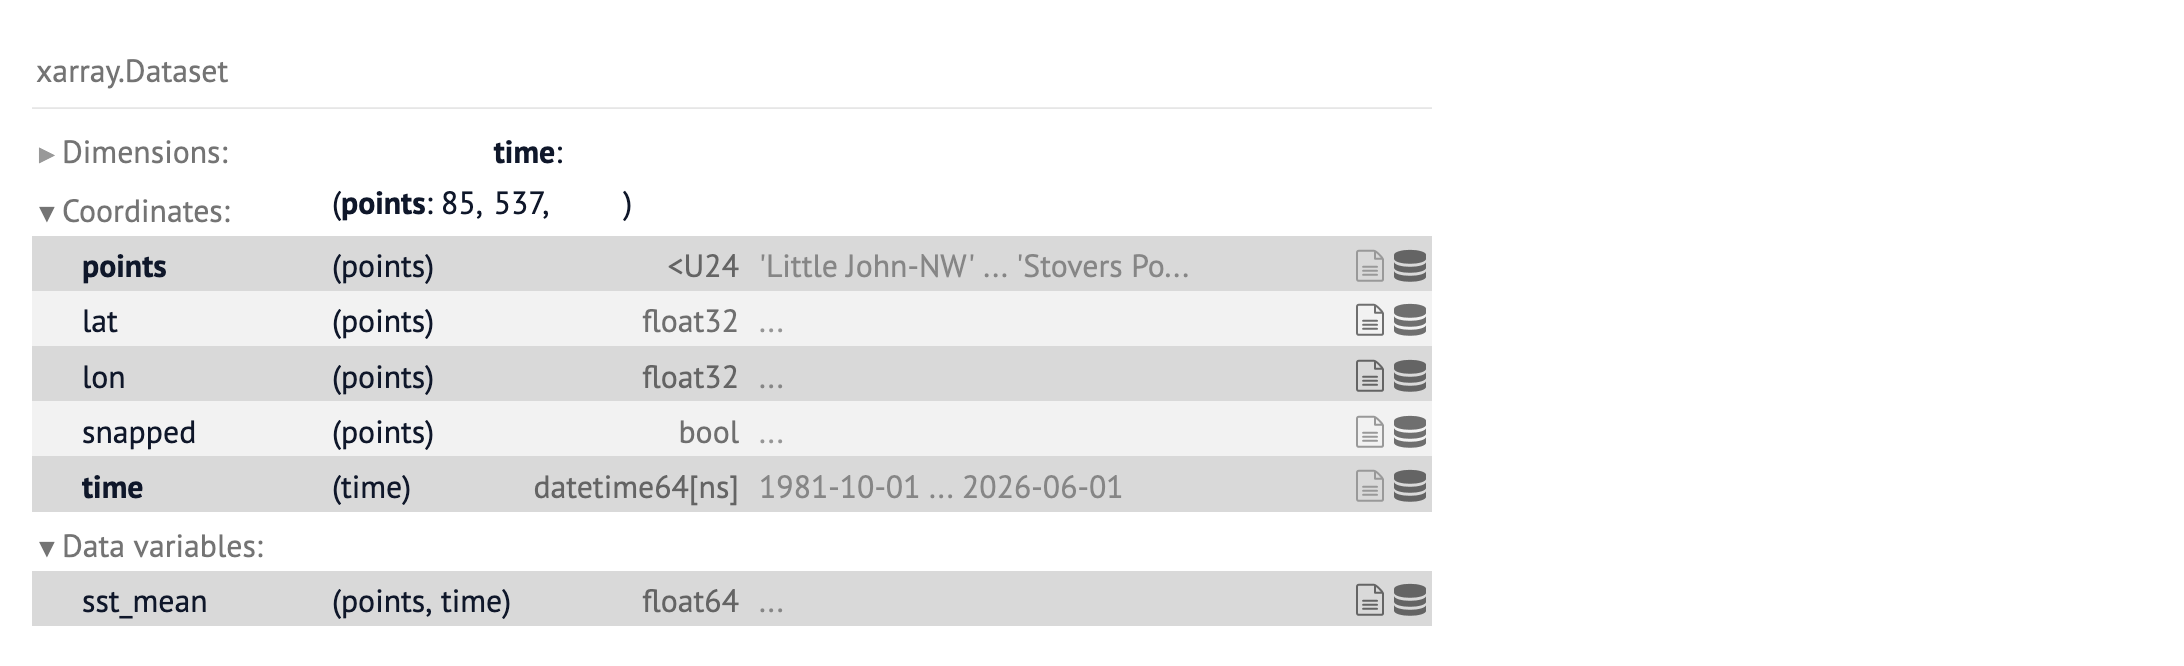

In [ ]:
points_sst_nc = xr.open_dataset("~/Downloads/oisst_points_sst_mean.nc")
points_sst_nc